**"Penerapan Metode Hybrid Stacking Berbasis Iterative Imputer dan SMOTE untuk Prediksi Kelayakan Air Minum"**

Link Dataset : https://www.kaggle.com/datasets/adityakadiwal/water-potability

Nama : Surya Farrel Fawwaz Assyarofi

Nim : 23.61.0258



---



##INSTALL & IMPORT

In [ ]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split

# IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# imbalance
from imblearn.over_sampling import SMOTE

# model
from xgboost import XGBClassifier

##DATA COLLECTION

In [ ]:
# load dataset
df = pd.read_csv("/content/drive/MyDrive/PDM 2026/Dataset /water_potability.csv")

# lihat data
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


##Exploratory Data Analysis


###Struktur Data & Statistik

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


###Missing Value Analysis

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


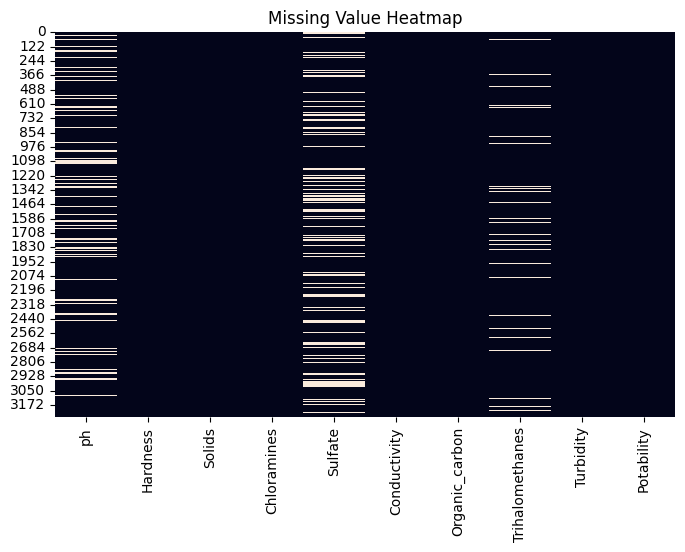

In [ ]:
missing = df.isnull().sum()
print(missing)

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

###Distribusi Target (Imbalance Check)

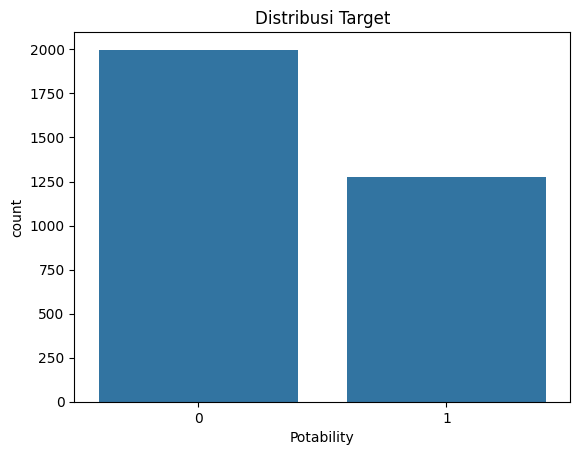

Potability
0    1998
1    1278
Name: count, dtype: int64
Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='Potability', data=df)
plt.title("Distribusi Target")
plt.show()

print(df['Potability'].value_counts())
print(df['Potability'].value_counts(normalize=True))

###Distribusi Setiap Fitur

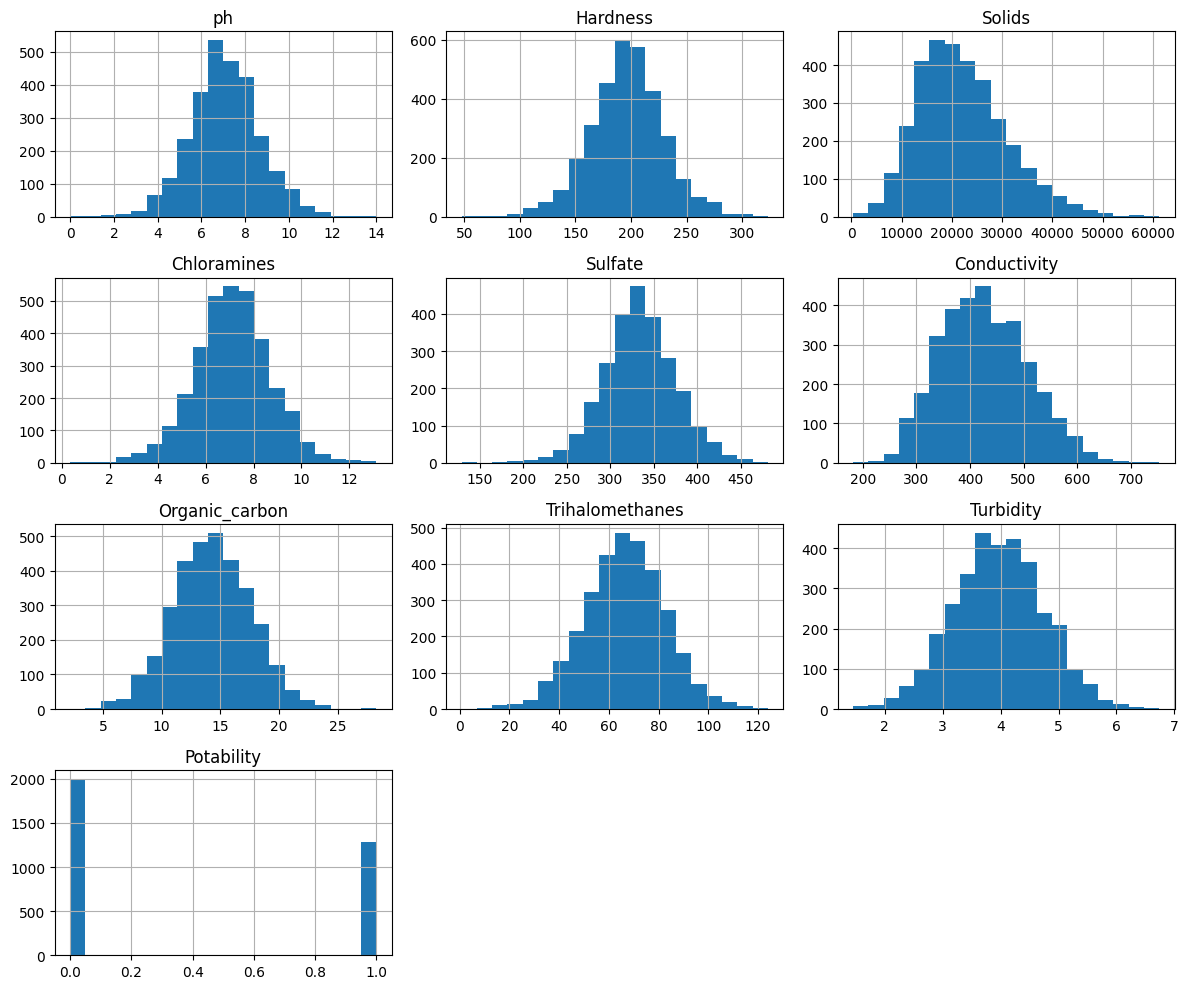

In [ ]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

###Korelasi Antar Fitur

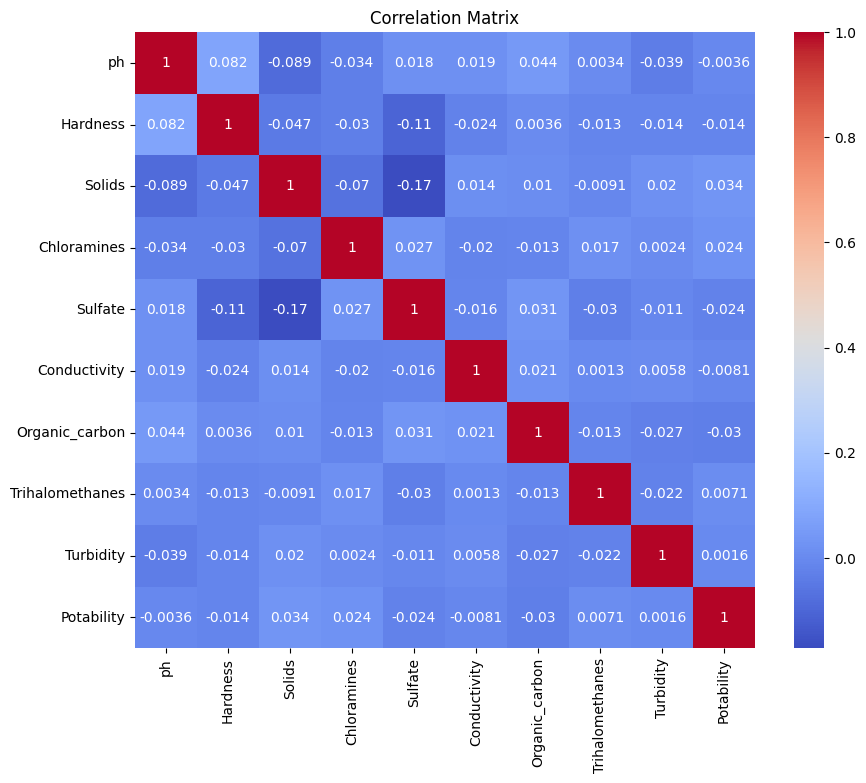

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

###Boxplot (Deteksi Outlier)

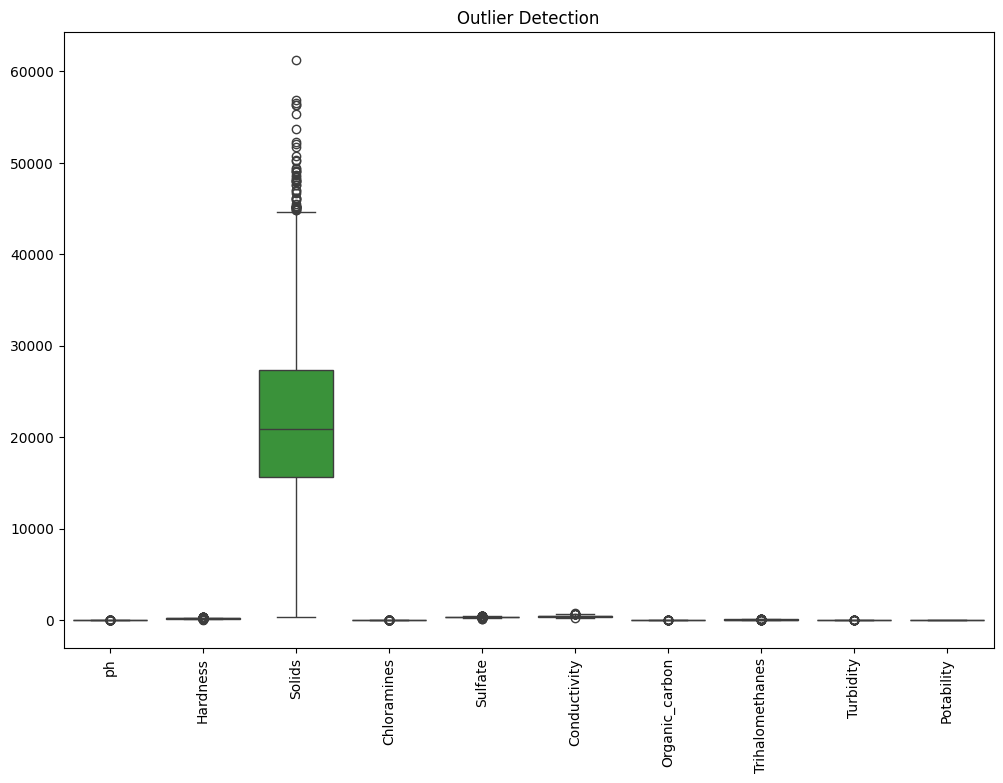

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

###Hubungan Fitur dengan Target

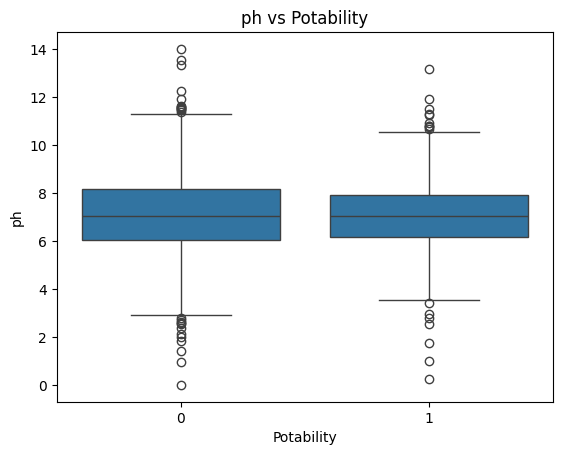

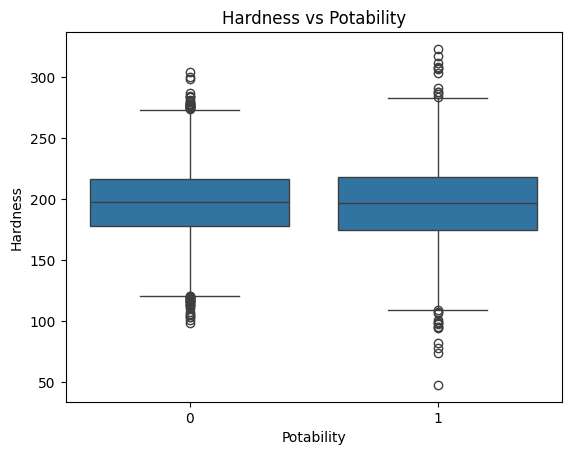

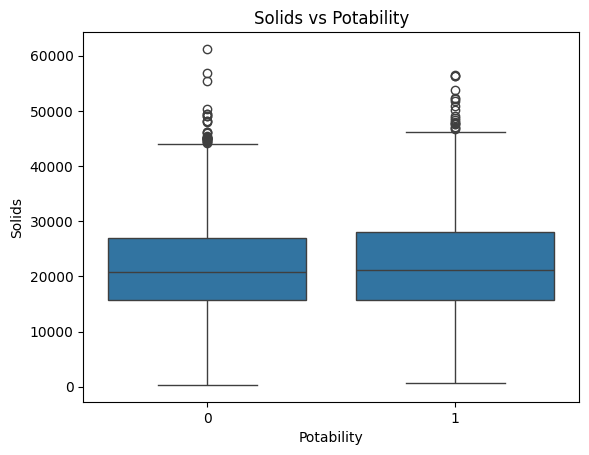

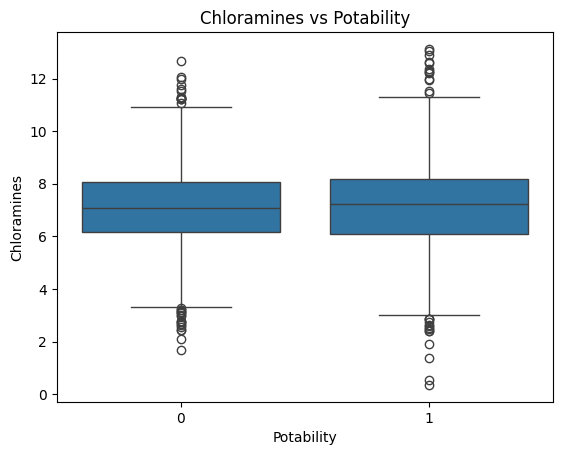

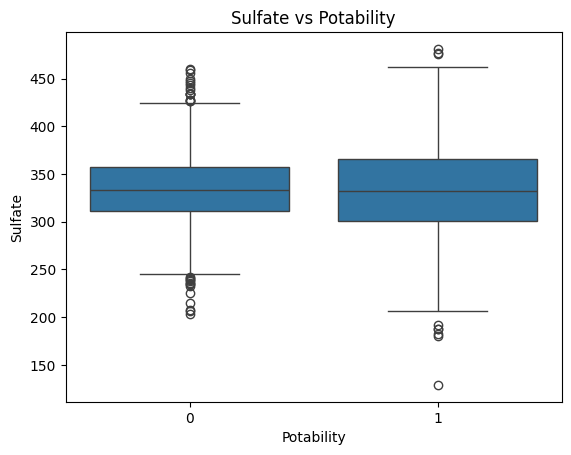

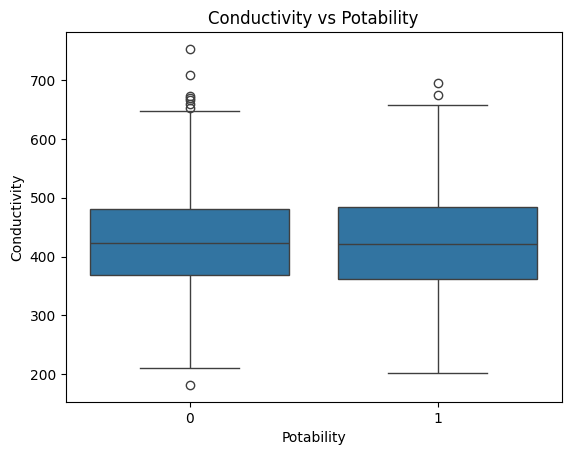

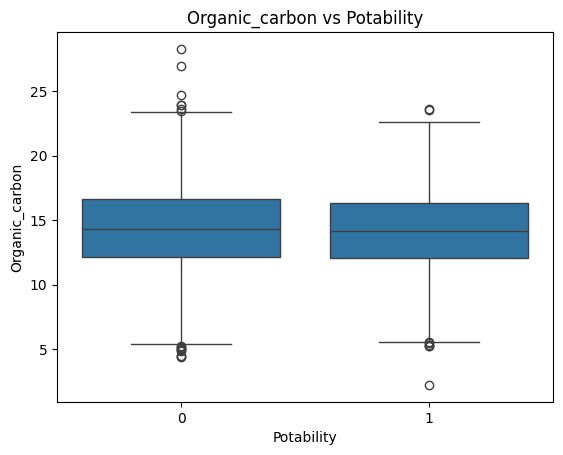

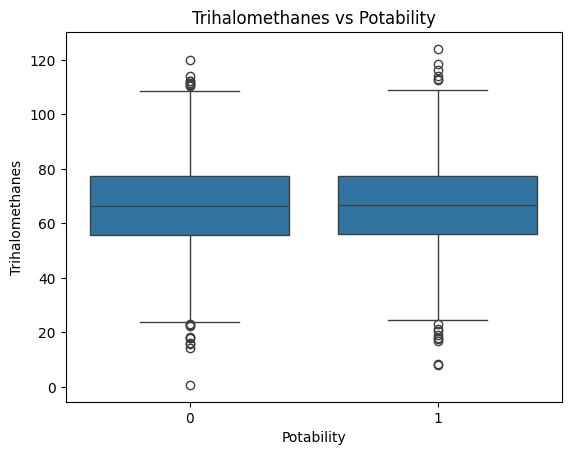

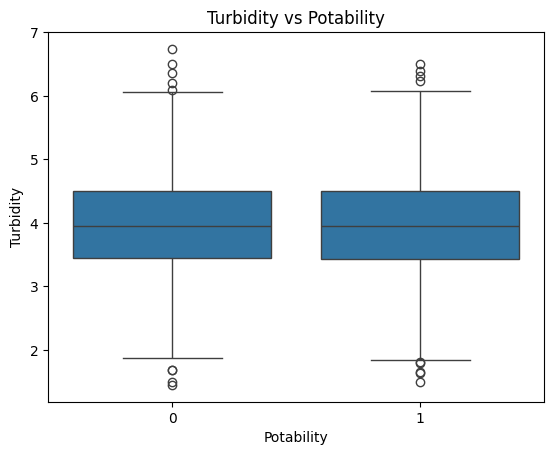

In [ ]:
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x='Potability', y=col, data=df)
    plt.title(f"{col} vs Potability")
    plt.show()

###Pairplot

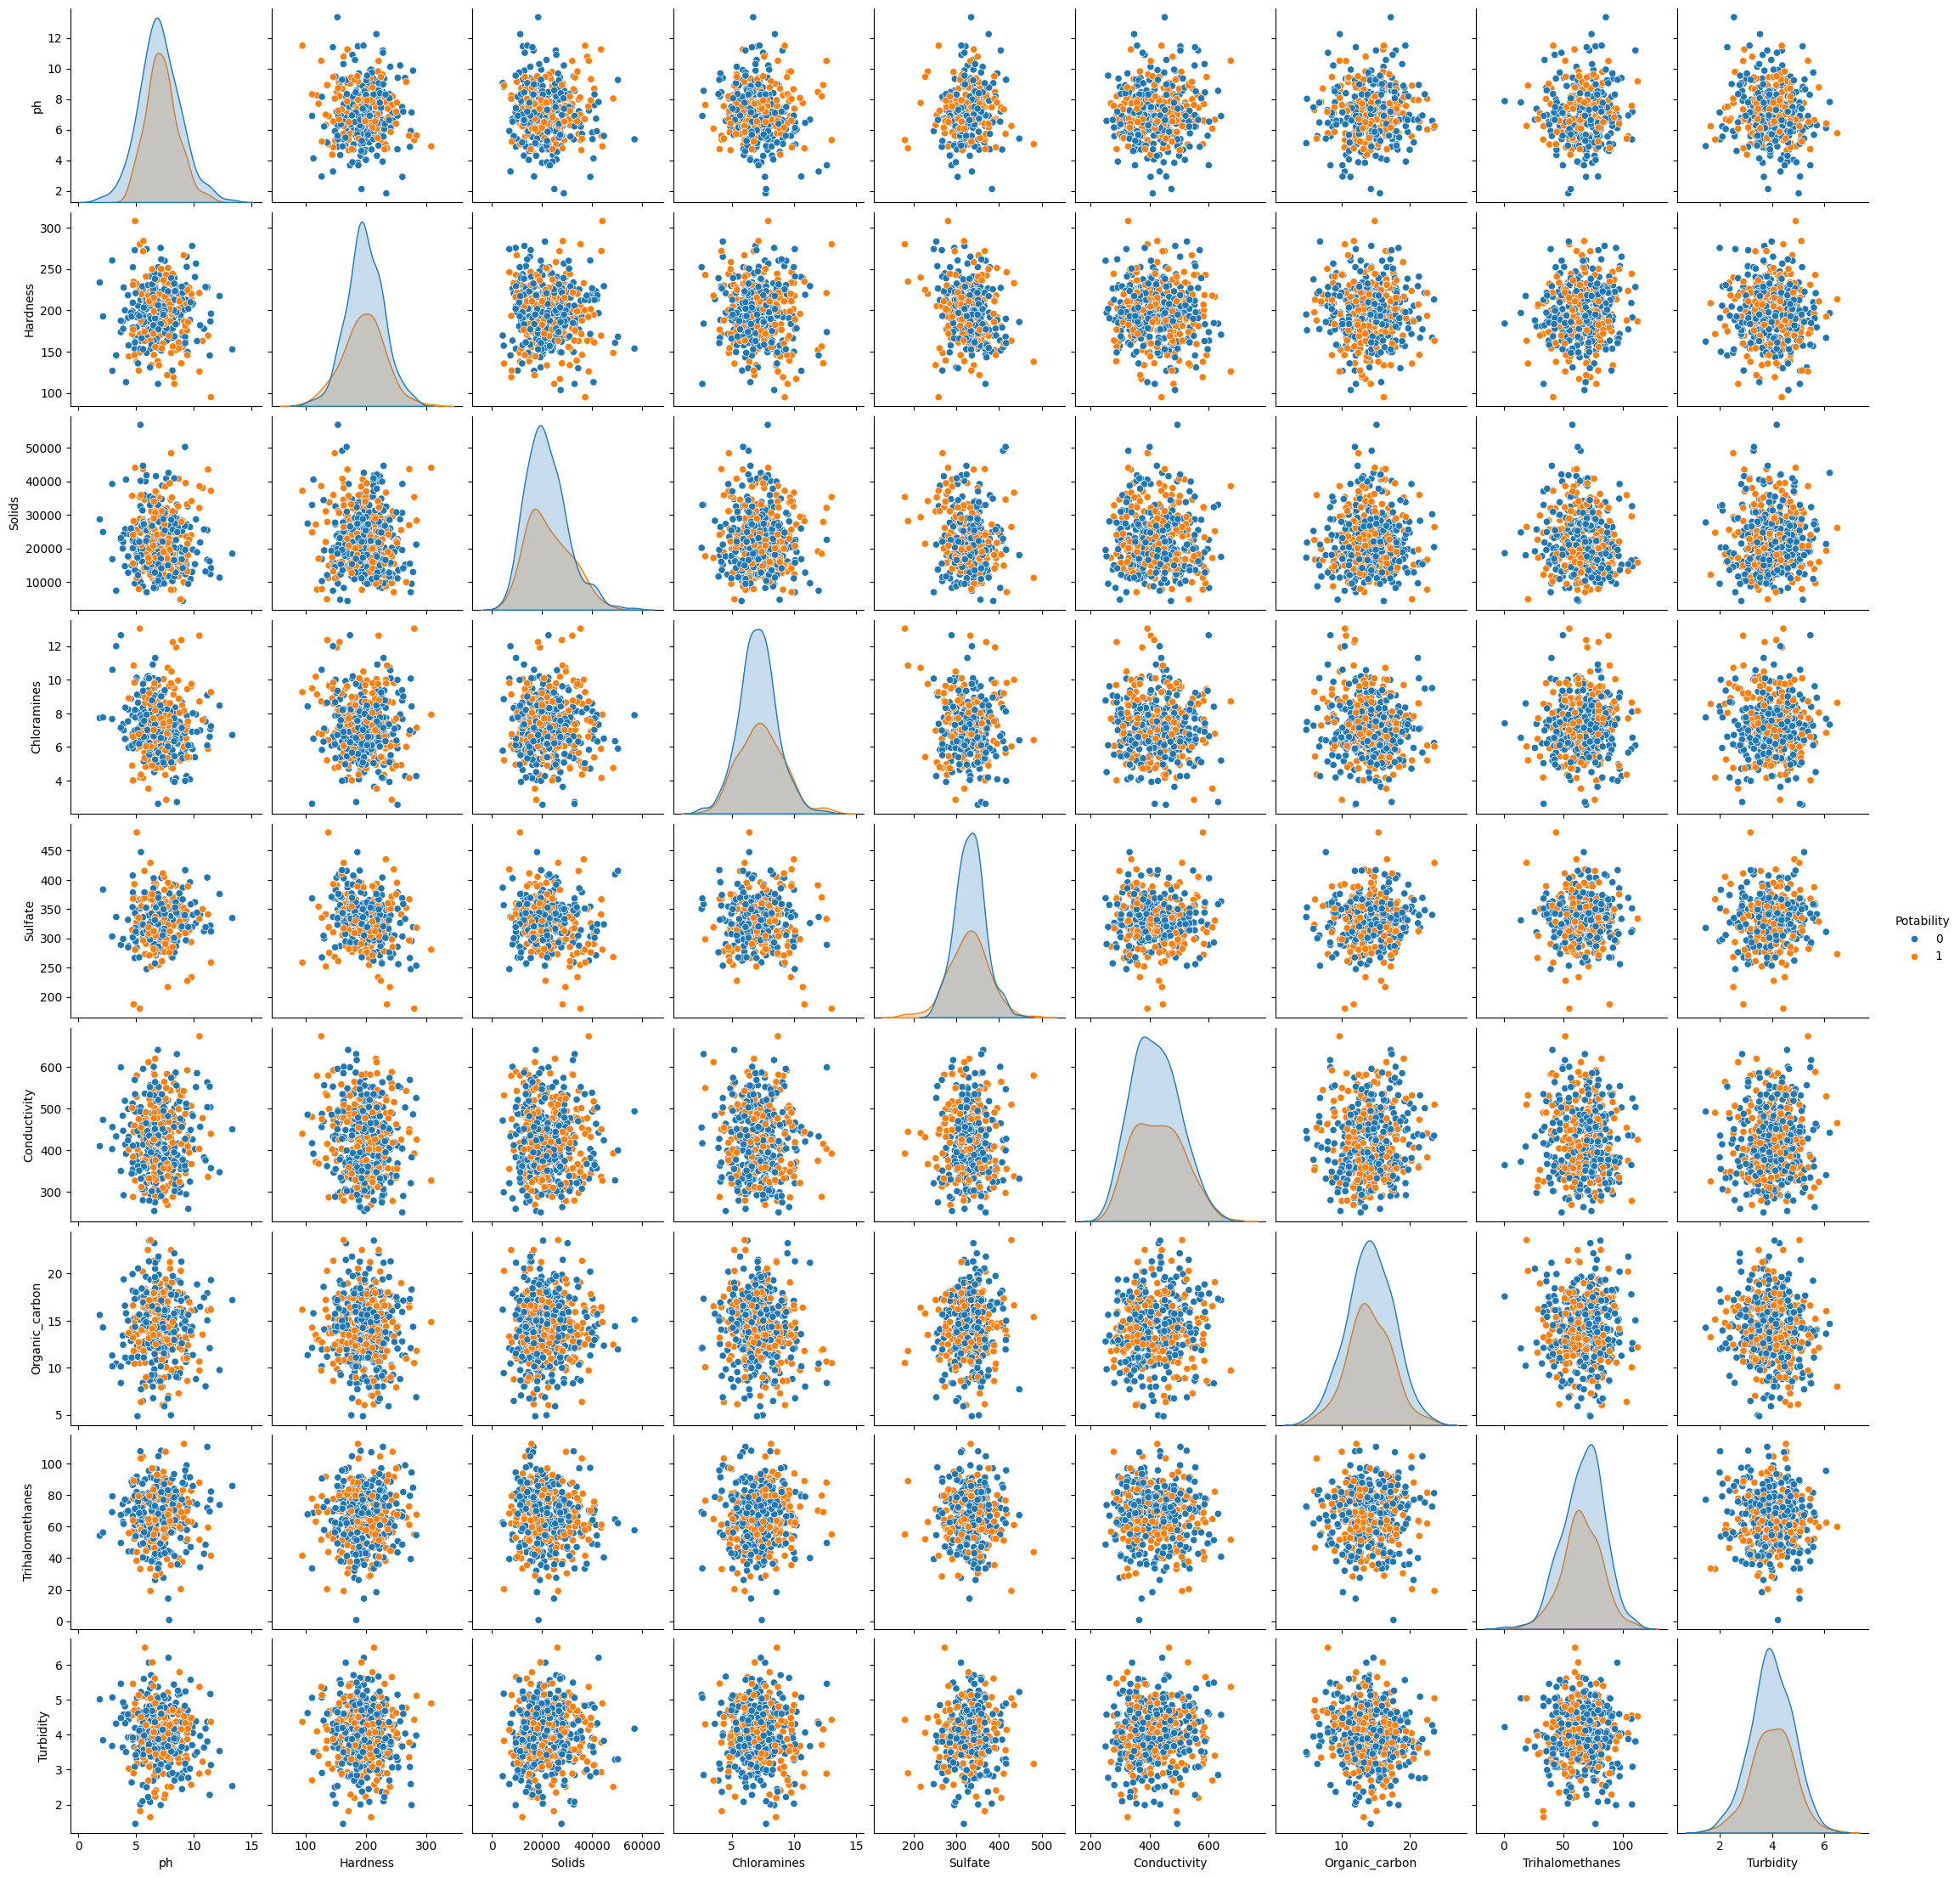

In [ ]:
sns.pairplot(df.sample(500), hue='Potability')
plt.show()

###Skewness (Distribusi Data)

In [ ]:
print(df.skew())

ph                 0.025630
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.035947
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.083031
Turbidity         -0.007817
Potability         0.450784
dtype: float64


###Outlier check

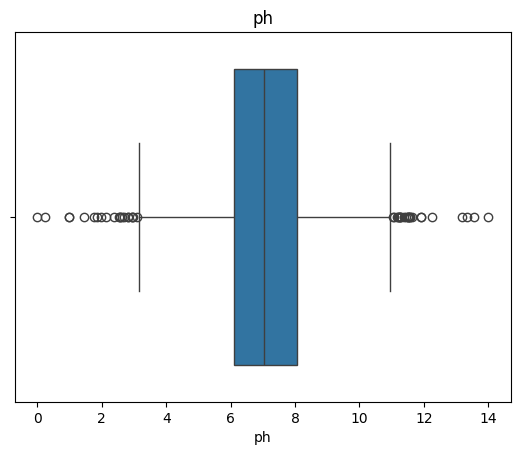

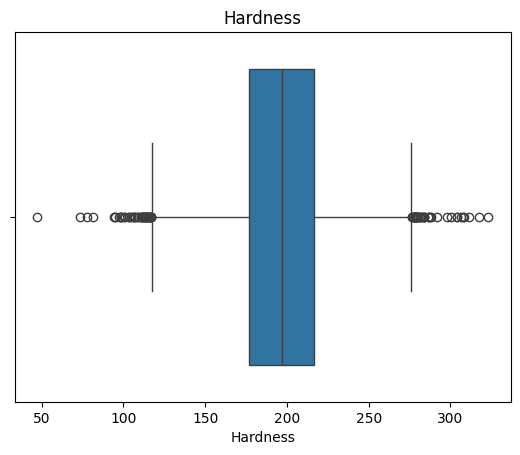

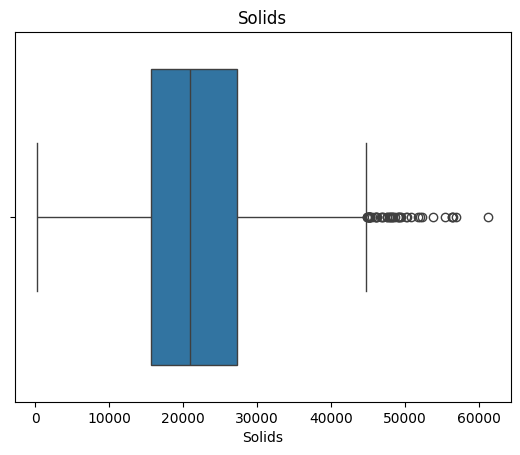

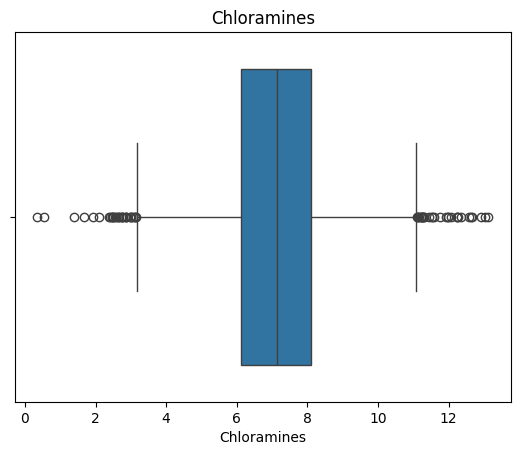

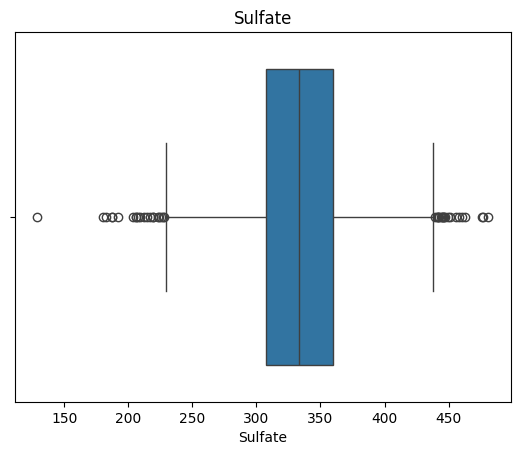

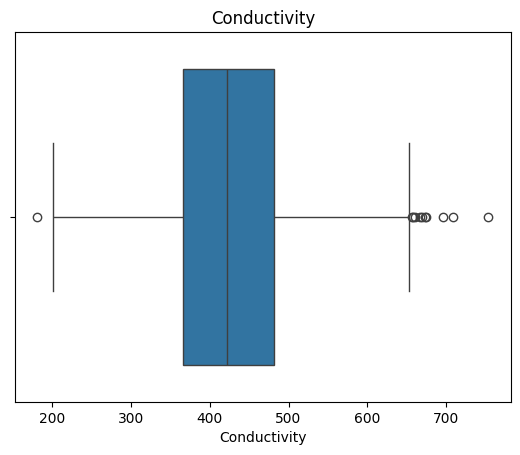

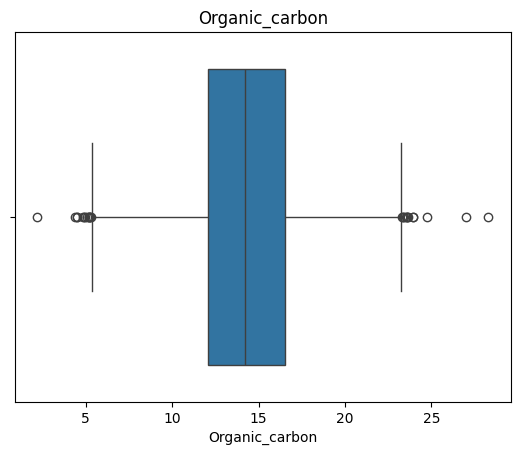

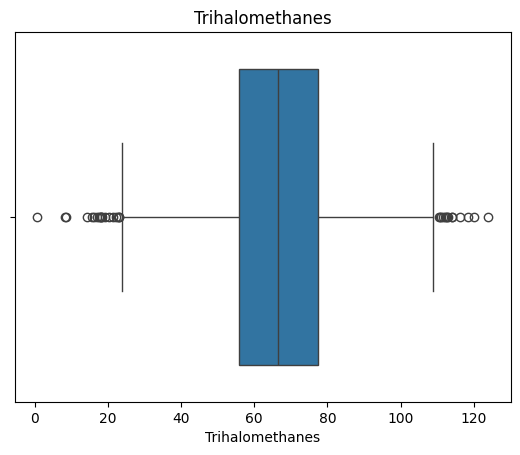

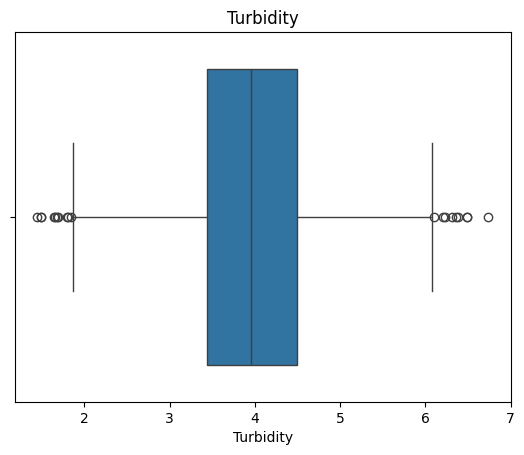

In [ ]:
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()



---



##DATA PREPROCESSING

###Pisah fitur & target

In [ ]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

###Cek Missing Value (Before)


In [ ]:
print("=== SEBELUM IMPUTATION ===")
print(df.isnull().sum())

=== SEBELUM IMPUTATION ===
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


###HANDLE MISSING VALUE (Iterative Imputer)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42)
X = imputer.fit_transform(X)

# balik jadi dataframe
X = pd.DataFrame(X, columns=df.columns[:-1])

###Cek Missing Value (After)

In [ ]:
print("=== SETELAH IMPUTATION ===")
print(X.isnull().sum())

=== SETELAH IMPUTATION ===
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


###HANDLE IMBALANCE (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

###SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##MODELING (XGBoost)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Assuming best_xgb_model and best_rf_model are available from previous tuning steps.
# If not, you might need to re-run the tuning for these models.

# 1. Definisikan Base Estimators (Model Dasar)
# Menggunakan model terbaik yang telah dituning sebelumnya
# Memastikan best_xgb_model dan best_rf_model sudah ada dari eksekusi sebelumnya

# Placeholder check - you might need to ensure these variables exist
# For the purpose of this response, I'm assuming 'best_xgb_model' and 'best_rf_model' exist in the kernel state

# If best_xgb_model is not defined, use a default tuned version or the previously defined xgb_model_tuned
if 'best_xgb_model' not in locals():
    # Fallback if best_xgb_model was not preserved or defined
    print("Warning: 'best_xgb_model' not found. Using a default tuned XGBoost.")
    best_xgb_model = XGBClassifier(random_state=42)

# If best_rf_model is not defined, use a default tuned version or the previously defined best_rf_model
if 'best_rf_model' not in locals():
    # Fallback if best_rf_model was not preserved or defined
    print("Warning: 'best_rf_model' not found. Using a default tuned RandomForest.")
    best_rf_model = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=20) # Example of a common tuned RF


estimators = [
    ('xgb', best_xgb_model),
    ('rf', best_rf_model),
    ('knn', KNeighborsClassifier())
]

# 2. Definisikan Stacking Classifier dengan Meta-Learner (Logistic Regression)
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(solver='liblinear', random_state=42),
    cv=5,
    n_jobs=-1
)

# 3. Proses Training Model
print("Training StackingClassifier with tuned base estimators...")
stack_clf.fit(X_train, y_train)

# 4. Proses Prediksi (Menggunakan Data Uji)
print("Menggenerasikan prediksi pada data uji...")
y_pred_stack_clf = stack_clf.predict(X_test)


Training StackingClassifier with tuned base estimators...
Menggenerasikan prediksi pada data uji...


##Feature Importance

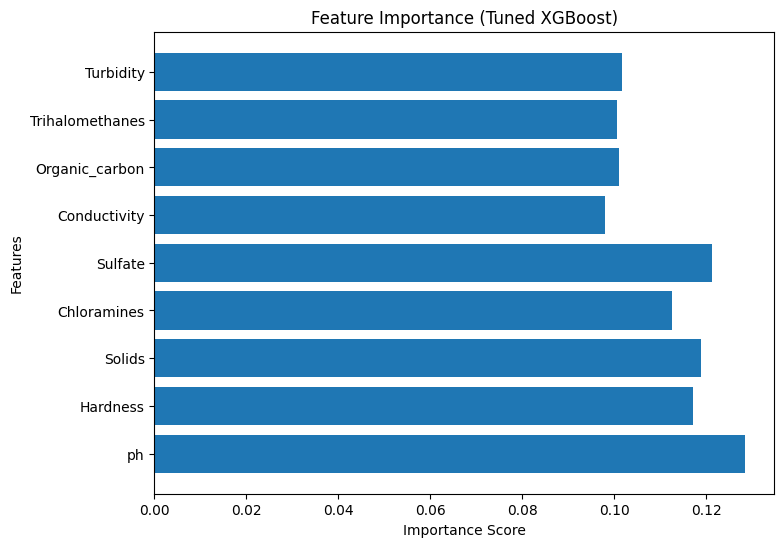

In [ ]:
# Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(df.columns[:-1], best_xgb_model.feature_importances_)
plt.title("Feature Importance (Tuned XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

##EVALUASI

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("=== StackingClassifier Model Evaluation (with Tuned Base Estimators) ===")
current_accuracy = accuracy_score(y_test, y_pred_stack_clf)
print(f"Accuracy: {current_accuracy}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack_clf))

# Now, let's proceed with tuning the final estimator (LogisticRegression) of the StackingClassifier.
# We will use the corrected param_grid_stacking_final that was mentioned in the context.

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for the final_estimator (LogisticRegression)
# Using the corrected param_grid_stacking_final
param_grid_stacking_final = [
    {
        'final_estimator__C': [1, 10], # Reduced values for faster tuning
        'final_estimator__solver': ['liblinear'],
        'final_estimator__penalty': ['l1', 'l2']
    },
    {
        'final_estimator__C': [1, 10], # Reduced values for faster tuning
        'final_estimator__solver': ['lbfgs'],
        'final_estimator__penalty': ['l2'] # lbfgs only supports l2 penalty
    }
]

# Initialize GridSearchCV
grid_search_stacking_final = GridSearchCV(
    stack_clf, # Use the current stack_clf with tuned base estimators
    param_grid=param_grid_stacking_final,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV for StackingClassifier's final_estimator...")
grid_search_stacking_final.fit(X_train, y_train)

# Get the best final estimator
best_stack_clf_final = grid_search_stacking_final.best_estimator_

print("Best parameters for StackingClassifier final_estimator:", grid_search_stacking_final.best_params_)

# Make predictions with the best stacking classifier
y_pred_best_stack_tuned_final = best_stack_clf_final.predict(X_test)

# Evaluate the best stacking classifier
print("\n=== Final StackingClassifier Model Evaluation (with Tuned Final Estimator) ===")
final_tuned_accuracy = accuracy_score(y_test, y_pred_best_stack_tuned_final)
print(f"Accuracy: {final_tuned_accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred_best_stack_tuned_final))

=== StackingClassifier Model Evaluation (with Tuned Base Estimators) ===
Accuracy: 0.7375

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.74      0.73       394
           1       0.74      0.74      0.74       406

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800


Starting GridSearchCV for StackingClassifier's final_estimator...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for StackingClassifier final_estimator: {'final_estimator__C': 10, 'final_estimator__penalty': 'l1', 'final_estimator__solver': 'liblinear'}

=== Final StackingClassifier Model Evaluation (with Tuned Final Estimator) ===
Accuracy: 0.73625
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.74      0.73       394
           1       0.74      0.74      0.74

In [ ]:
import joblib

# Menyimpan model stacking terbaik hasil tuning ke dalam file biner
joblib.dump(best_stack_clf_final, 'model_stacking_air.pkl')
print("Model 'model_stacking_air.pkl' berhasil disimpan di folder kamu!")

Model 'model_stacking_air.pkl' berhasil disimpan di folder kamu!


In [ ]:
# Simpan scaler bersama model
joblib.dump(scaler, 'scaler_air.pkl')
joblib.dump(best_stack_clf_final, 'model_stacking_air.pkl')

['model_stacking_air.pkl']

In [ ]:
# contoh data yang Potability = 1 (layak minum)
contoh_layak = df[df['Potability'] == 1].dropna().head(5)
print(contoh_layak.to_string())

           ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability
250  9.445130  145.805402  13168.529156     9.444471  310.583374    592.659021        8.606397        77.577460   3.875165           1
251  9.024845  128.096691  19859.676476     8.016423  300.150377    451.143481       14.770863        73.778026   3.985251           1
253  6.800119  242.008082  39143.403329     9.501695  187.170714    376.456593       11.432466        73.777275   3.854940           1
254  7.174135  203.408935  20401.102461     7.681806  287.085679    315.549900       14.533510        74.405616   3.939896           1
255  7.657991  236.960889  14245.789121     6.289065  373.165363    416.624189       10.464239        85.852769   2.437296           1


In [ ]:
# SEMUA data yang layak
contoh_layak = df[df['Potability'] == 1].dropna()
print(f"Total data layak: {len(contoh_layak)}")
print(contoh_layak.to_string())

Total data layak: 811
             ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability
250    9.445130  145.805402  13168.529156     9.444471  310.583374    592.659021        8.606397        77.577460   3.875165           1
251    9.024845  128.096691  19859.676476     8.016423  300.150377    451.143481       14.770863        73.778026   3.985251           1
253    6.800119  242.008082  39143.403329     9.501695  187.170714    376.456593       11.432466        73.777275   3.854940           1
254    7.174135  203.408935  20401.102461     7.681806  287.085679    315.549900       14.533510        74.405616   3.939896           1
255    7.657991  236.960889  14245.789121     6.289065  373.165363    416.624189       10.464239        85.852769   2.437296           1
256    8.322987  207.252462  28049.646283     8.827061  297.813085    358.725869       18.709273        60.911420   4.052136           1
258    9.802721   9